Saved: ../../analysis/pdfs/cifar100_imagenet_object_ratio_paper.pdf


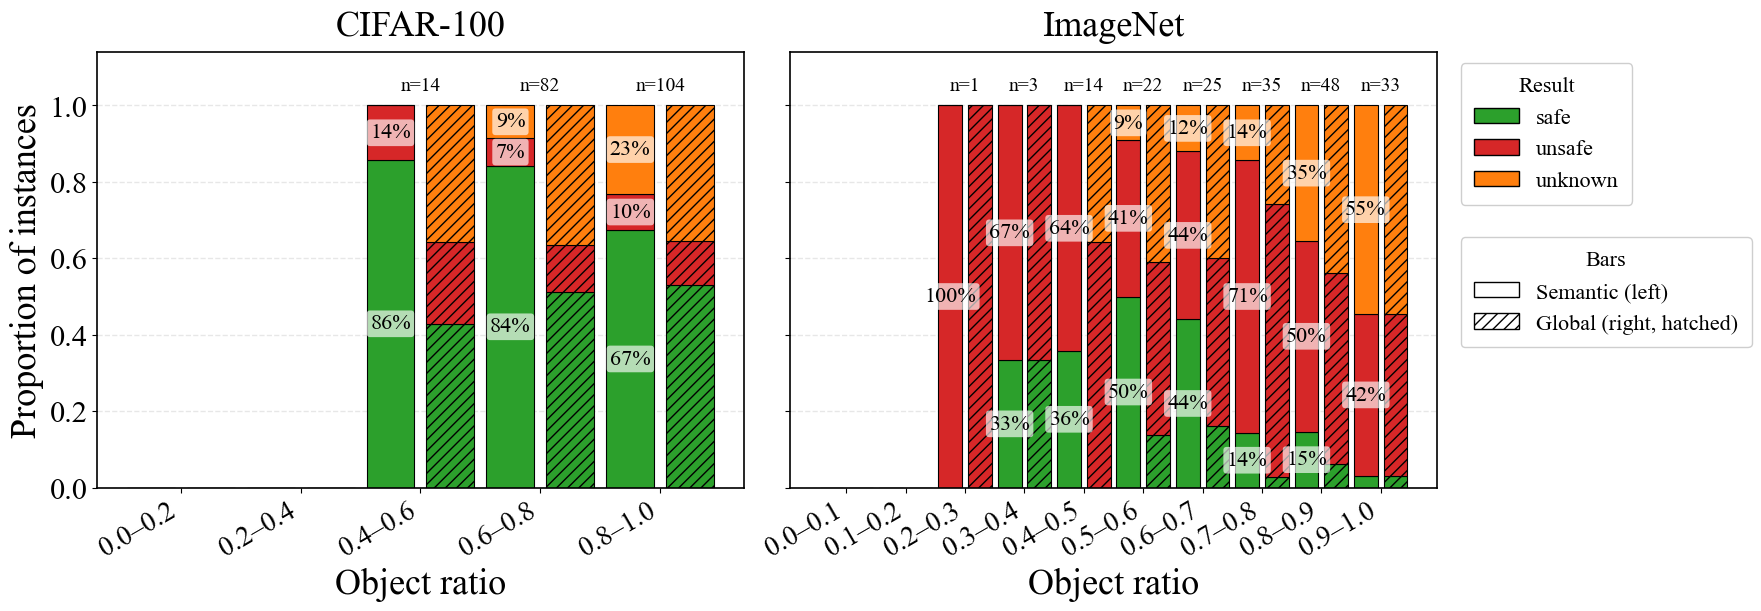

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------
# Paper-ready / LaTeX-friendly style
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # BIGGER fonts
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 22,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,

    # Lines / grid
    "axes.linewidth": 1.2,
    "grid.linewidth": 1.0,

    # PDF text as real text (best for LaTeX)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Paths (EDIT)
# ---------------------------

CIFAR_CSV   = "../../results/cifar100_segmented/combined_results.csv"
IMAGENET_CSV = "../../analysis/csvs/ALL_vggnet_triplets_merged.csv"

# ---------------------------
# Result canonicalization
# ---------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown"

COLOR = {"safe": "#2ca02c", "unknown": "#ff7f0e", "unsafe": "#d62728"}
ORDER = ["safe", "unsafe", "unknown"]

def _make_bins(n_bins):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    labels = [f"{edges[i]:.1f}–{edges[i+1]:.1f}" for i in range(n_bins)]
    return edges, labels

def _stacked_props(series_bins, series_result, bin_labels):
    counts = (
        pd.crosstab(series_bins, series_result)
        .reindex(bin_labels)
        .fillna(0)
    )
    n = counts.sum(axis=1).astype(int)
    props = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    return props, n

def compute_semantic_vs_global_by_obj_ratio(
    df,
    *,
    key_global,
    key_obj,
    tag_obj="fix_nonmask",
    tag_global="global",
    n_bins=10,
    require_total=None,
    require_full_k=True
):
    d = df.copy()

    # numeric cleanup
    for c in ["eps", "k", "total", "segment_index", "num_changed"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    for c in ["tag", "model", "image"]:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

    d = d.dropna(subset=["total", "k"]).copy()

    if require_total is not None:
        d = d[d["total"].astype(int) == int(require_total)].copy()

    if require_full_k:
        d["full_k"] = (d["total"] // 3).astype(int)
        d = d[d["k"].astype(int) == d["full_k"]].copy()

    d = d[d["tag"].isin([tag_obj, tag_global])].copy()
    if d.empty:
        raise ValueError("After filtering tags/total/k, dataframe is empty.")

    d["result_cat"] = d["result"].apply(canon_result)

    obj = d[d["tag"] == tag_obj][key_obj + ["num_changed", "result_cat"]].copy()
    glb = d[d["tag"] == tag_global][key_global + ["result_cat"]].copy()

    if obj.empty:
        raise ValueError(f"No rows found for object tag='{tag_obj}'.")
    if glb.empty:
        raise ValueError(
            f"No rows found for global tag='{tag_global}'. "
            f"(Your CSV may not contain 'global' runs.)"
        )

    obj = obj.rename(columns={"num_changed": "obj_changed", "result_cat": "sem_result"})
    glb = glb.rename(columns={"result_cat": "glb_result"}).drop_duplicates(subset=key_global, keep="first")

    paired = obj.merge(glb, on=key_global, how="left")
    if paired["glb_result"].isna().any():
        missing = int(paired["glb_result"].isna().sum())
        print(f"[WARN] Missing global result for {missing} object rows (after merge). Dropping those rows.")
        paired = paired.dropna(subset=["glb_result"]).copy()

    edges, bin_labels = _make_bins(n_bins)

    paired["obj_ratio"] = paired["obj_changed"] / paired["total"]
    paired["obj_bin"] = pd.cut(paired["obj_ratio"], bins=edges, labels=bin_labels, include_lowest=True)

    props_sem, n_per_bin = _stacked_props(paired["obj_bin"], paired["sem_result"], bin_labels)
    props_glb, _         = _stacked_props(paired["obj_bin"], paired["glb_result"], bin_labels)

    return props_sem, props_glb, n_per_bin, bin_labels

def draw_grouped_stacked_sem_vs_global(
    ax,
    props_sem,
    props_glb,
    n_per_bin,
    xlabels,
    *,
    xlabel="Object ratio",
    title="",
    width=0.40,
    gap=0.10,
    hatch_glb="///",
    show_pct_on_sem=True,
    pct_thresh=0.06,       # lower threshold so more labels appear (still readable)
    show_n=True
):
    x = np.arange(len(xlabels))
    xS = x - (width/2 + gap/2)  # Semantic
    xG = x + (width/2 + gap/2)  # Global

    bottomS = np.zeros(len(xlabels))
    bottomG = np.zeros(len(xlabels))

    for lab in ORDER:
        valsS = props_sem.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values
        valsG = props_glb.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values

        ax.bar(xS, valsS, bottom=bottomS, width=width,
               color=COLOR[lab], edgecolor="black", linewidth=0.8)
        ax.bar(xG, valsG, bottom=bottomG, width=width,
               color=COLOR[lab], edgecolor="black", linewidth=0.8, hatch=hatch_glb)

        # Bigger percent labels (semantic only), with a small white bbox behind
        if show_pct_on_sem:
            for j, v in enumerate(valsS):
                if v >= pct_thresh:
                    ax.text(
                        xS[j],
                        bottomS[j] + v/2,
                        f"{v*100:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=16,
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, boxstyle="round,pad=0.15")
                    )

        bottomS += valsS
        bottomG += valsG

    if show_n:
        n_vals = n_per_bin.reindex(xlabels).fillna(0).astype(int).values
        for j, n in enumerate(n_vals):
            if n > 0:
                ax.text(
                    x[j],
                    1.03,
                    f"n={n}",
                    ha="center",
                    va="bottom",
                    fontsize=14
                )

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha="right")
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1.14)

    ax.grid(axis="y", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)

# ============================================================
# Load both datasets
# ============================================================
df_cifar = pd.read_csv(CIFAR_CSV)
df_imnet = pd.read_csv(IMAGENET_CSV)

# ------------------------------------------------------------
# CIFAR-100
# expects tag in {fix_nonmask, global} for semantic vs global
# ------------------------------------------------------------
KEY_G_CIFAR = [c for c in ["model", "image", "eps", "k", "total"] if c in df_cifar.columns]
KEY_O_CIFAR = [c for c in ["model", "image", "segment_index", "eps", "k", "total"] if c in df_cifar.columns]

props_c_sem, props_c_glb, n_c, labels_c = compute_semantic_vs_global_by_obj_ratio(
    df_cifar,
    key_global=KEY_G_CIFAR,
    key_obj=KEY_O_CIFAR,
    tag_obj="fix_nonmask",
    tag_global="global",
    n_bins=5,
    require_total=None,
    require_full_k=True
)

# ------------------------------------------------------------
# ImageNet
# ------------------------------------------------------------
KEY_G_IM = [c for c in ["image", "eps", "k", "total"] if c in df_imnet.columns]
KEY_O_IM = [c for c in ["image", "segment_index", "eps", "k", "total"] if c in df_imnet.columns]

props_i_sem, props_i_glb, n_i, labels_i = compute_semantic_vs_global_by_obj_ratio(
    df_imnet,
    key_global=KEY_G_IM,
    key_obj=KEY_O_IM,
    tag_obj="fix_nonmask",
    tag_global="global",
    n_bins=10,
    require_total=150528,
    require_full_k=True
)

# ============================================================
# Plot: single figure, two panels (NO bottom (a)/(b) captions)
# ============================================================
fig, (axL, axR) = plt.subplots(
    1, 2,
    figsize=(17.5, 6.0),
    sharey=True,
    constrained_layout=True
)

draw_grouped_stacked_sem_vs_global(
    axL, props_c_sem, props_c_glb, n_c, labels_c,
    xlabel="Object ratio",
    title="CIFAR-100",
    hatch_glb="///",
    show_pct_on_sem=True,
    pct_thresh=0.06,
    show_n=True
)
axL.set_ylabel("Proportion of instances")

draw_grouped_stacked_sem_vs_global(
    axR, props_i_sem, props_i_glb, n_i, labels_i,
    xlabel="Object ratio",
    title="ImageNet",
    hatch_glb="///",
    show_pct_on_sem=True,
    pct_thresh=0.06,
    show_n=True
)

# Legend outside right panel (keep clean, paper-like)
handles_results = [mpl.patches.Patch(facecolor=COLOR[k], edgecolor="black", label=k) for k in ORDER]
handles_bars = [
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Semantic (left)", hatch=""),
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Global (right, hatched)", hatch="///"),
]
leg1 = axR.legend(handles=handles_results, title="Result",
                  loc="upper left", bbox_to_anchor=(1.02, 1.00),
                  frameon=True, fancybox=True, framealpha=0.95, borderpad=0.6)
axR.add_artist(leg1)
axR.legend(handles=handles_bars, title="Bars",
           loc="upper left", bbox_to_anchor=(1.02, 0.60),
           frameon=True, fancybox=True, framealpha=0.95, borderpad=0.6)

# Save (vector)
out_pdf = "cifar100_imagenet_object_ratio.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print("Saved:", out_pdf)

plt.show()
